<div align="center">

#### [S. Mussard](https://sites.google.com/view/cv-stphane-mussard/accueil "Homepage") 

</div>

<div align="center">

#### Chapter 8: Gini Discriminant Analysis 

</div>


<div align="center"> <a href="https://www.python.org/"><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/f/f8/Python_logo_and_wordmark.svg/390px-Python_logo_and_wordmark.svg.png" style="max-width: 150px; display: inline" alt="Python"/></a> 

</div>


<div align="center"> </div>

<div align="center">

Cite: S. Mussard (2025), *Machine Learning with Gini Indices: Applications with Python*, Springer.  

</div>



In [1]:
from GDA import GiniAFD
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report 
from sklearn.metrics import confusion_matrix

# Data
from sklearn.datasets import load_iris  
data = load_iris()
y = np.array(data.target)
X = np.array(data.data)
print(data.DESCR)




.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [2]:
# Train and Summary
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
nu = 1.1
model = GiniAFD(gini_param=nu)
model.fit(x_train,y_train)
# model.fit(x_train,y_train, nb_components=2)
model.summary()

                        Generalized Gini Discriminant Analyses                       
Target Variable:                       y     No. of features                        4
No. of classes                         3     Sample size                          120
No. Outliers in X:                     3     Gini parameter (nu)                  1.1
Date:                   Sat, 27 Sep 2025     Time:                           13:55:13

        Table of Eigenvalues
   Eigenvalues        %  Cumsum %
0      14.3926  99.5458   99.5458
1       0.2983   2.0632  101.6090
2      -0.0006  -0.0045  101.6045
3      -0.2320  -1.6045  100.0000

Stats for discriminant axis 1:
-----------------------------------
    Correlation  p_value
X1       0.7646      0.0
X2      -0.5290      0.0
X3       0.9745      0.0
X4       0.9678      0.0
-----------------------------------
Stats for discriminant axis 2:
-----------------------------------
    Correlation  p_value
X1       0.3483   0.0001
X2       0.7841   0.0000

In [3]:
# Table: Coordinates of points over the discr. axes
import pandas as pd
y_train = np.reshape(y_train, (y_train.shape[0], 1)) # reshape into vector (n,1)
axis_1 = np.reshape(model.discriminant_axes,(y_train.shape[0], 3))
concat = np.concatenate((y_train,axis_1), axis=1)
df = pd.DataFrame(concat, columns = ["Iris Classes", "Axis 1", "Axis 2", "Axis 3"])

# Centroids per groups over the discriminant axes
centroids = df.groupby(by="Iris Classes").mean()
print("Centroids:", "\n", centroids)


Centroids: 
                   Axis 1      Axis 2    Axis 3
Iris Classes                                  
0.0          -819.661251    0.704094  3.123208
1.0           180.712941 -167.153175  3.601615
2.0           574.554772  139.936541 -5.796929


<Axes: >

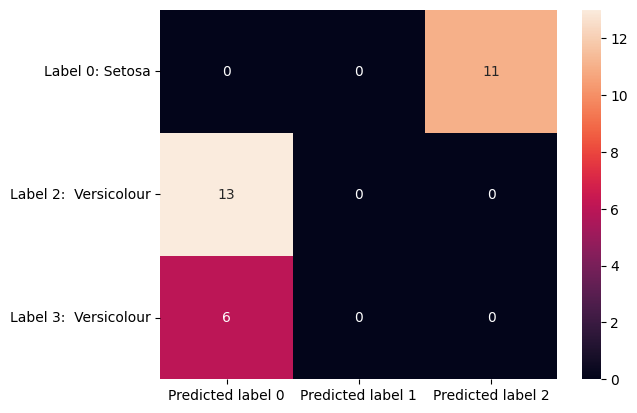

In [4]:
# Confusion matrix
import seaborn as sns
from sklearn import metrics

y_pred = model.predict(x_test, y_test, method="gini_estimator")
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
cf_matrix = pd.DataFrame(confusion_matrix, index = ['Label 0: Setosa', 'Label 2:  Versicolour', 'Label 3:  Versicolour'], columns = ['Predicted label 0','Predicted label 1', 'Predicted label 2'])
cf_matrix
sns.heatmap(cf_matrix, annot=True)

In [5]:
# Classification report

y_pred = model.predict(x_test, y_test, method="geometric_gini")
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.92      0.92      0.92        13
           2       0.83      0.83      0.83         6

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30



## Wine

In [6]:
# Wine
from sklearn.datasets import load_wine 
data = load_wine()

# GDA
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
nu_values = np.arange(1.1, 4, 0.1)
classif_methods = ["euclidean_gini", "geometric_gini", "homo_gini", "hetero_gini"]
nu = 1.1
model = GiniAFD(gini_param=nu)
model.fit(x_train,y_train)
model.grid_search(x_train, y_train, x_test, y_test, nu_values, classif_methods, nb_components=2)
model.summary()

# LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
clf = LinearDiscriminantAnalysis()
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)
accuracy = accuracy_score(y_test.flatten(), y_pred)
print("Acurracy of LDA sklearn", accuracy )

                  Gridsearch: Best Model
     Best nu:      Max accuracy:             Method:
0         1.8           0.966667      geometric_gini
 
                        Performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.93      1.00      0.96        13
           2       1.00      0.83      0.91         6

    accuracy                           0.97        30
   macro avg       0.98      0.94      0.96        30
weighted avg       0.97      0.97      0.97        30

                        Generalized Gini Discriminant Analyses                       
Target Variable:                       y     No. of features                        4
No. of classes                         3     Sample size                          120
No. Outliers in X:                     3     Gini parameter (nu)   3.9000000000000026
Date:                   Sat, 27 Sep 2025     Time:                           13:55:14

   

In [7]:
# Kold
nu_values = np.arange(1.1, 4, 0.1)
classif_methods = ["euclidean_gini", "geometric_gini", "homo_gini", "hetero_gini"]
nu = 1.1
model = GiniAFD(gini_param=nu)
model.fit(X,y) # fit is mandatory 
model.grid_search_kfold(X, y, nu_values, classif_methods, nb_components=2, n_splits=5)
model.summary()

                  Gridsearch: Best Model
Best nu: 3.1
Max accuracy: 0.97
Method: geometric_gini
                        Performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.92      0.98      0.95        50
           2       0.98      0.92      0.95        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150

                        Generalized Gini Discriminant Analyses                       
Target Variable:                       y     No. of features                        4
No. of classes                         3     Sample size                          120
No. Outliers in X:                     3     Gini parameter (nu)    3.100000000000002
Date:                   Sat, 27 Sep 2025     Time:                           13:55:17

        Table of Eigenvalues
   Eigenvalues        %  Cu

In [8]:
# KFold LDA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []
for train_index, test_index in kf.split(X):
    X_train, x_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    clf = LinearDiscriminantAnalysis()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test.flatten(), y_pred)
    accuracies.append(accuracy)
mean_accuracy = np.mean(accuracies)
print("Mean Accuracy:", mean_accuracy)

Mean Accuracy: 0.9800000000000001


## Breast cancer

In [9]:
# Breast cancer
from sklearn.datasets import load_breast_cancer 
data = load_breast_cancer()
y = np.array(data.target)
X = np.array(data.data)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
nu_values = np.arange(1.1, 4, 0.1)
classif_methods = ["euclidean_gini", "geometric_gini", "homo_gini", "hetero_gini"]
nu = 1.1
model = GiniAFD(gini_param=nu)
model.fit(x_train,y_train)
model.grid_search(x_train, y_train, x_test, y_test, nu_values, classif_methods, nb_components=2)
model.summary()

                  Gridsearch: Best Model
     Best nu:      Max accuracy:             Method:
0         1.5           0.973684      geometric_gini
 
                        Performance
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        47
           1       0.97      0.99      0.98        67

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

                        Generalized Gini Discriminant Analyses                       
Target Variable:                       y     No. of features                       30
No. of classes                         1     Sample size                          455
No. Outliers in X:                    29     Gini parameter (nu)   3.9000000000000026
Date:                   Sat, 27 Sep 2025     Time:                           13:55:21

        Table of Eigenvalues
Empty DataFrame
Columns: [Ei

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
# LDA
clf = LinearDiscriminantAnalysis()
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)
accuracy = accuracy_score(y_test.flatten(), y_pred)
print("Acurracy of LDA sklearn", accuracy )

Acurracy of LDA sklearn 0.9649122807017544


In [11]:
# Kfold
nu_values = np.arange(1.1, 4, 0.1)
classif_methods = ["euclidean_gini", "geometric_gini", "homo_gini", "hetero_gini"]
nu = 1.1
model = GiniAFD(gini_param=nu)
model.fit(X,y) # Fit is mandatory 
model.grid_search_kfold(X, y, nu_values, classif_methods, nb_components=2, n_splits=5)
model.summary()

                  Gridsearch: Best Model
Best nu: 1.5
Max accuracy: 0.91
Method: geometric_gini
                        Performance
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       212
           1       0.93      0.92      0.92       357

    accuracy                           0.91       569
   macro avg       0.90      0.90      0.90       569
weighted avg       0.91      0.91      0.91       569

                        Generalized Gini Discriminant Analyses                       
Target Variable:                       y     No. of features                       30
No. of classes                         1     Sample size                          456
No. Outliers in X:                    29     Gini parameter (nu)   1.5000000000000004
Date:                   Sat, 27 Sep 2025     Time:                           13:55:45

        Table of Eigenvalues
Empty DataFrame
Columns: [Eigenvalues, %, Cumsum %]
Index: []

Stats for discrimi

## Sonar

In [12]:
import pandas as pd
df = pd.read_excel('Sonar.xlsx')
y = df['Class'].to_numpy()
X = df.drop('Class', axis=1).to_numpy()
# Kfold
nu_values = np.arange(1.1, 4, 0.1)
classif_methods = ["euclidean_gini", "geometric_gini", "homo_gini", "hetero_gini"]
nu = 1.1
model = GiniAFD(gini_param=nu)
model.fit(X,y) # Fit is mandatory 
model.grid_search_kfold(X, y, nu_values, classif_methods, nb_components=2, n_splits=5)
model.summary()

                  Gridsearch: Best Model
Best nu: 1.9
Max accuracy: 0.75
Method: geometric_gini
                        Performance
              precision    recall  f1-score   support

           0       0.79      0.71      0.75       111
           1       0.70      0.78      0.74        97

    accuracy                           0.75       208
   macro avg       0.75      0.75      0.75       208
weighted avg       0.75      0.75      0.75       208

                        Generalized Gini Discriminant Analyses                       
Target Variable:                       y     No. of features                       60
No. of classes                         1     Sample size                          167
No. Outliers in X:                    59     Gini parameter (nu)   1.9000000000000008
Date:                   Sat, 27 Sep 2025     Time:                           13:56:15

        Table of Eigenvalues
Empty DataFrame
Columns: [Eigenvalues, %, Cumsum %]
Index: []

Stats for discrimi

In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []
for train_index, test_index in kf.split(X):
    X_train, x_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    clf = LinearDiscriminantAnalysis()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test.flatten(), y_pred)
    accuracies.append(accuracy)
mean_accuracy = np.mean(accuracies)
print("Mean Accuracy:", mean_accuracy)

Mean Accuracy: 0.7499419279907086
